# 01 — Business Understanding
**saas-churn-intelligence** | Indian Telecom Churn Prediction

> Goal: Frame the business problem, load the dataset, and define success metrics before any modelling.

In [1]:
import os; os.makedirs("../outputs", exist_ok=True); os.makedirs("../models", exist_ok=True)
# ── LIBRARIES ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("✅ Libraries loaded")

✅ Libraries loaded


## 1.1 Load Dataset

In [2]:
# ── PORTABLE PATH DETECTION ─────────────────────────────
def find_csv(name, candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Cannot find {name}. Place it in data/processed/")

DATA_PATH = find_csv("crm_churn_ml_ready.csv", [
    "../data/processed/crm_churn_ml_ready.csv",
    "data/processed/crm_churn_ml_ready.csv",
    "crm_churn_ml_ready.csv",
])

df = pd.read_csv(DATA_PATH)
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

✅ Loaded: 13,461 rows × 28 columns


,streaming_movies,number_of_referrals,total_extra_data_charges,multiple_lines,total_revenue,paperless_billing,phone_service,total_charges,internet_service,tenure_in_months,...,device_protection_plan,contract,monthly_charge,unlimited_data,married,streaming_music,payment_method,total_refunds,total_long_distance_charges,churn
0,No,7,0,No,974.81,Yes,Yes,593.30,Yes,27,...,No,One Year,65.6,Yes,No,No,Credit Card,0.00,381.51,0
1,Yes,14,10,Yes,610.28,No,Yes,542.40,Yes,13,...,No,Month-to-Month,-4.0,No,Yes,Yes,Credit Card,38.33,96.21,0
2,No,4,0,No,415.45,Yes,Yes,280.85,Yes,35,...,Yes,Month-to-Month,73.9,Yes,No,No,Bank Withdrawal,0.00,134.60,1
3,Yes,3,0,No,1599.51,Yes,Yes,1237.85,Yes,21,...,Yes,Month-to-Month,98.0,Yes,No,No,Bank Withdrawal,0.00,361.66,1
4,No,3,0,No,289.54,Yes,Yes,267.40,Yes,8,...,No,Month-to-Month,83.9,Yes,No,No,Credit Card,0.00,22.14,1


## 1.2 Dataset Overview

In [3]:
print("=" * 55)
print("  DATASET PROFILE")
print("=" * 55)
print(f"  Rows         : {df.shape[0]:,}")
print(f"  Columns      : {df.shape[1]}")
print(f"  Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
print("  Column types:")
for dtype, count in df.dtypes.value_counts().items():
    print(f"    {str(dtype):<12}: {count} columns")

  DATASET PROFILE
  Rows         : 13,461
  Columns      : 28
  Memory usage : 15.6 MB

  Column types:
    object      : 18 columns
    int64       : 5 columns
    float64     : 5 columns


In [4]:
# ── MISSING VALUES ──────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print((missing.to_frame("count")
       .assign(pct=lambda x: (x["count"]/len(df)*100).round(1))
       .to_string()))

Columns with missing values:
                        count   pct
internet_type            2916  21.7
streaming_movies         1390  10.3
streaming_tv             1390  10.3
online_security          1390  10.3
online_backup            1390  10.3
unlimited_data           1390  10.3
device_protection_plan   1390  10.3
streaming_music          1390  10.3
multiple_lines            622   4.6


## 1.3 Target Variable — Churn Distribution

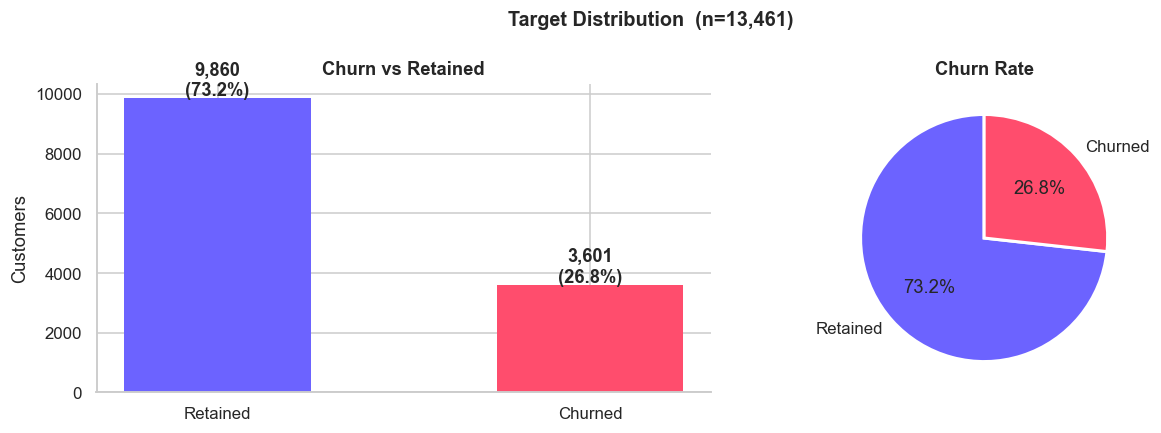

Churn rate: 26.8%  →  Class imbalance: YES — handled with oversampling in notebook 04


In [5]:
churn_counts = df["churn"].value_counts()
churn_pct    = df["churn"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ["#6c63ff", "#ff4d6d"]
axes[0].bar(["Retained", "Churned"], churn_counts.values, color=colors, width=0.5, edgecolor="none")
for i, (cnt, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, cnt + 80, f"{cnt:,}\n({pct:.1f}%)", ha="center", fontweight="bold")
axes[0].set_title("Churn vs Retained", fontweight="bold")
axes[0].set_ylabel("Customers")

# Pie
axes[1].pie(churn_counts.values, labels=["Retained", "Churned"],
            colors=colors, autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Churn Rate", fontweight="bold")

plt.suptitle(f"Target Distribution  (n={len(df):,})", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/01_churn_distribution.png", bbox_inches="tight", dpi=110)
plt.show()
print(f"Churn rate: {churn_pct[1]:.1f}%  →  Class imbalance: YES — handled with oversampling in notebook 04")

## 1.4 Business Problem Framing

In [6]:
# ── COST OF CHURN ───────────────────────────────────────
avg_monthly   = df["monthly_charge"].median()
avg_tenure    = df.groupby("churn")["tenure_in_months"].mean()
churners      = df[df["churn"] == 1]
retention_mo  = 18   # months saved customer stays after intervention
intervention  = 50   # $ cost per outreach

revenue_per_save = avg_monthly * retention_mo

print("=" * 55)
print("  BUSINESS COST MODEL")
print("=" * 55)
print(f"  Avg monthly charge (median) : ${avg_monthly:.2f}")
print(f"  Avg tenure — retained       : {avg_tenure[0]:.0f} months")
print(f"  Avg tenure — churned        : {avg_tenure[1]:.0f} months")
print()
print(f"  Revenue saved per customer  : ${revenue_per_save:,.0f}")
print(f"    = ${avg_monthly:.2f}/mo × {retention_mo} months retained")
print(f"  Intervention cost           : ${intervention}/customer")
print(f"  Net value per correct catch : ${revenue_per_save - intervention:,.0f}")
print()
print(f"  Total churners in dataset   : {len(churners):,}")
print(f"  Max recoverable revenue     : ${len(churners) * revenue_per_save:,.0f}")

  BUSINESS COST MODEL
  Avg monthly charge (median) : $70.20
  Avg tenure — retained       : 28 months
  Avg tenure — churned        : 18 months

  Revenue saved per customer  : $1,264
    = $70.20/mo × 18 months retained
  Intervention cost           : $50/customer
  Net value per correct catch : $1,214

  Total churners in dataset   : 3,601
  Max recoverable revenue     : $4,550,224


## 1.5 Success Metrics

In [7]:
metrics = {
    "ROC-AUC"          : "> 0.85  (model discriminates well)",
    "Recall (churn)"   : "> 75%   (catch most at-risk customers)",
    "Precision (churn)": "> 55%   (keep intervention cost viable)",
    "Net Revenue Saved": "> $2M   (vs baseline of $0)",
}

print("SUCCESS CRITERIA")
print("-" * 50)
for metric, target in metrics.items():
    print(f"  {metric:<22}: {target}")
print()
print("PRIMARY METRIC: Recall — missing a churner ($1,264 loss)")
print("costs far more than a false alarm ($50 intervention).")

SUCCESS CRITERIA
--------------------------------------------------
  ROC-AUC               : > 0.85  (model discriminates well)
  Recall (churn)        : > 75%   (catch most at-risk customers)
  Precision (churn)     : > 55%   (keep intervention cost viable)
  Net Revenue Saved     : > $2M   (vs baseline of $0)

PRIMARY METRIC: Recall — missing a churner ($1,264 loss)
costs far more than a false alarm ($50 intervention).


## 1.6 Key Columns Reference

In [8]:
col_reference = {
    "contract"           : "Contract type — strongest churn driver",
    "monthly_charge"     : "Customer's monthly bill ($)",
    "tenure_in_months"   : "How long the customer has been with us",
    "internet_type"      : "DSL / Fiber Optic / Cable",
    "number_of_referrals": "# of referrals made (loyalty signal)",
    "total_revenue"      : "Lifetime revenue from customer",
    "age"                : "Customer age",
    "payment_method"     : "How customer pays",
    "churn"              : "TARGET — 1=churned, 0=retained",
}

print(f"{'Column':<30} {'Description'}")
print("-" * 65)
for col, desc in col_reference.items():
    present = "✅" if col in df.columns else "❌"
    print(f"  {present} {col:<28} {desc}")

print(f"\nDataset ready for EDA → proceed to 02_data_exploration.ipynb")

Column                         Description
-----------------------------------------------------------------
  ✅ contract                     Contract type — strongest churn driver
  ✅ monthly_charge               Customer's monthly bill ($)
  ✅ tenure_in_months             How long the customer has been with us
  ✅ internet_type                DSL / Fiber Optic / Cable
  ✅ number_of_referrals          # of referrals made (loyalty signal)
  ✅ total_revenue                Lifetime revenue from customer
  ✅ age                          Customer age
  ✅ payment_method               How customer pays
  ✅ churn                        TARGET — 1=churned, 0=retained

Dataset ready for EDA → proceed to 02_data_exploration.ipynb
